# Scope decisions and weak-form supportability

**Current surface:** V0.29.

## Purpose

Teach how PDELie communicates careful negative and partial results: weak-form supportability, KdV frozen-scope decisions, and the KS no-go status.

## What you will learn

- How `summarize_weak_form_supportability(...)` separates frozen Heat/Burgers weak reports from diagnostic-only feasibility.
- Why KdV remains stable only in the normalized short-horizon strong path.
- Why KS remains internal no-go evidence unless a separate promotion release opens.
- How to read decision reports without turning them into public API claims.

## Required extras

Core install plus Matplotlib for tutorial plots. The examples use public APIs only.

## Expected runtime

About 1-2 minutes; KdV fitting is the slowest cell.

## Out of scope

No WSINDy implementation, no weak derivative backend, no weak KdV/KS API, no public KS runtime API, no broad KdV regime promotion.


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from notebooks._tutorial_utils import plot_component_statuses, plot_label_strip, pretty_json
from pdelie.examples import run_kdv_scope_decision_example, run_weak_form_supportability_example

CONFIG = {"show_full_reports": False}
CONFIG


{'show_full_reports': False}

## 1. Weak reports: supported slice versus diagnostic-only evidence

Weak-form reports are useful, but V0.29 still does not expose a general weak derivative backend or WSINDy design matrix. The supportability label is intentionally categorical.


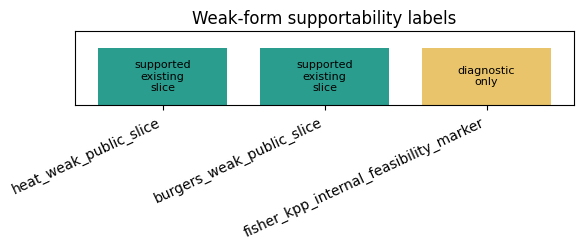

{
  "burgers_weak_public_slice": {
    "contract_quadrature": "composite_tensor_product_trapezoidal_native_window",
    "label": "supported_existing_slice",
    "weak_report_status": "passed"
  },
  "fisher_kpp_internal_feasibility_marker": {
    "contract_quadrature": null,
    "label": "diagnostic_only",
    "weak_report_status": "unavailable"
  },
  "heat_weak_public_slice": {
    "contract_quadrature": "composite_tensor_product_trapezoidal_native_window",
    "label": "supported_existing_slice",
    "weak_report_status": "passed"
  }
}


In [2]:
weak_example = run_weak_form_supportability_example()
weak_cases = {case["case_name"]: case["supportability"] for case in weak_example["cases"]}
plot_label_strip(
    {name: report["supportability_label"] for name, report in weak_cases.items()},
    title="Weak-form supportability labels",
)
print(pretty_json({
    name: {
        "label": report["supportability_label"],
        "weak_report_status": report["component_statuses"]["weak_report"]["status"],
        "contract_quadrature": None if report["weak_contract"] is None else report["weak_contract"]["quadrature_rule"],
    }
    for name, report in weak_cases.items()
}, max_chars=4500))


## 2. KdV: strong-path supported, broader scope deferred

The KdV example is a release-decision report. It demonstrates the frozen normalized scalar 1D periodic short-horizon strong path and records what remains deferred.


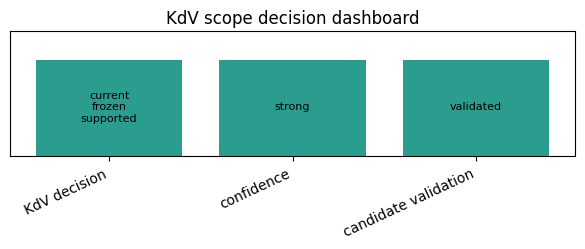

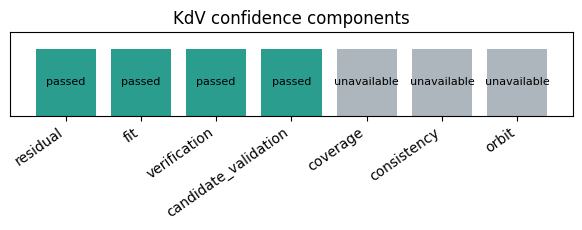

{
  "conclusion": "keep_public_kdv_surface_frozen",
  "deferred": [
    "custom_kdv_initial_conditions",
    "configurable_kdv_coefficients",
    "general_kdv_regime",
    "weak_kdv"
  ],
  "fallback_used": false,
  "fit_evidence": "direct_svd_in_tolerance",
  "public_scope": "normalized_scalar_1d_periodic_short_horizon_strong_kdv"
}


In [3]:
kdv = run_kdv_scope_decision_example()
kdv_current = kdv["current_frozen_path"]
plot_label_strip(
    {
        "KdV decision": kdv["decision"]["evidence_category"],
        "confidence": kdv_current["confidence"]["confidence_label"],
        "candidate validation": kdv_current["candidate_validation"]["conclusion"],
    },
    title="KdV scope decision dashboard",
)
plot_component_statuses(kdv_current["confidence"], title="KdV confidence components")
print(pretty_json({
    "public_scope": kdv["decision"]["public_scope"],
    "conclusion": kdv["decision"]["conclusion"],
    "deferred": [item["decision"] for item in kdv["deferred_decisions"]],
    "fit_evidence": kdv["extra_metrics"]["fit_evidence_label"],
    "fallback_used": kdv["extra_metrics"]["reference_fallback_used"],
}, max_chars=3500))


## 3. KS: status marker only, not a public workflow

KS is intentionally not imported from package examples. The V0.26 decision evidence lives in internal tests and release docs. The notebook keeps a static marker so users see the boundary instead of searching for a nonexistent public API.


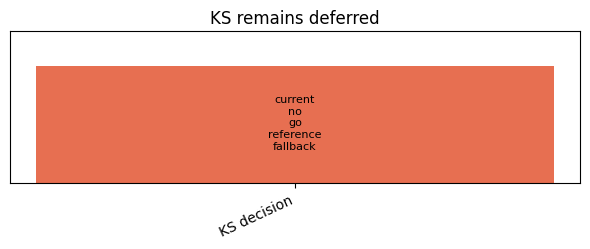

{
  "decision_label": "current_no_go_reference_fallback",
  "interpretation": "KS residual feasibility is not enough for public generator workflow promotion.",
  "public_runtime_apis": {
    "KSResidualEvaluator": false,
    "generate_ks_1d_field_batch": false,
    "run_ks_vertical_slice_example": false,
    "weak_ks": false
  },
  "summary_type": "ks_revisit_status_marker",
  "v0_26b_reserved_for_actual_promotion": true,
  "visibility": "documented_internal_diagnostic_only"
}


In [4]:
ks_status = {
    "summary_type": "ks_revisit_status_marker",
    "visibility": "documented_internal_diagnostic_only",
    "decision_label": "current_no_go_reference_fallback",
    "v0_26b_reserved_for_actual_promotion": True,
    "public_runtime_apis": {
        "generate_ks_1d_field_batch": False,
        "KSResidualEvaluator": False,
        "run_ks_vertical_slice_example": False,
        "weak_ks": False,
    },
    "interpretation": "KS residual feasibility is not enough for public generator workflow promotion.",
}
plot_label_strip({"KS decision": ks_status["decision_label"]}, title="KS remains deferred")
print(pretty_json(ks_status, max_chars=2500))


## Recap

PDELie reports what is supported, what is diagnostic-only, and what is explicitly deferred. That is part of the library design, not a lack of ambition.

## Common pitfalls

- Reading weak supportability as WSINDy or a weak derivative backend.
- Reading KdV success as general KdV support.
- Looking for public KS APIs after a no-go decision.
- Treating a release-decision JSON report as a mathematical theorem.

## Extension ideas

- Compare weak supportability thresholds on Heat and Burgers.
- Route KdV confidence components into your own experiment log.
- Use this notebook as a template for documenting future go/no-go decisions.

## What to read/run next

Run `11_multi_generator_diagnostics.ipynb` for algebraic diagnostics, or return to `00_pde_timeseries_to_generators.ipynb` for the stable strong-path workflow.
